In [12]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("..")

from src.modelo import crearModelo
from src.CocoDataset import CocoDataset
import torch

ds = CocoDataset("../data/raw/football-players/valid")
modelo = crearModelo(congelarBackbone=False,ligero=False)
modelo.load_state_dict(torch.load("../outputs/modelo_experimento_ResNet.pt", map_location=torch.device('cpu')))
modelo.eval()


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

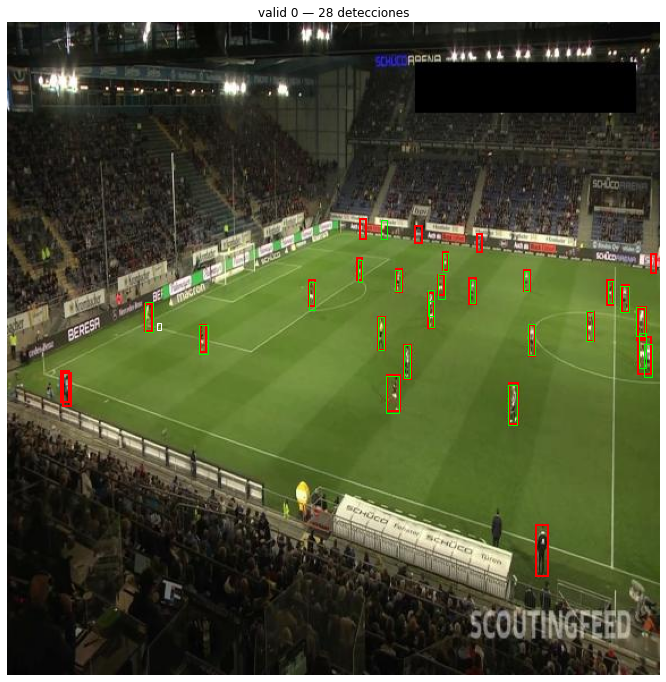

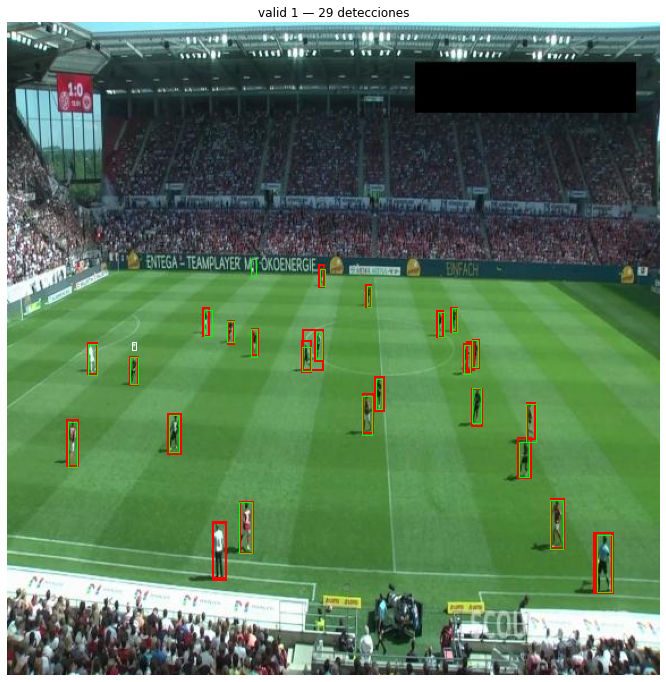

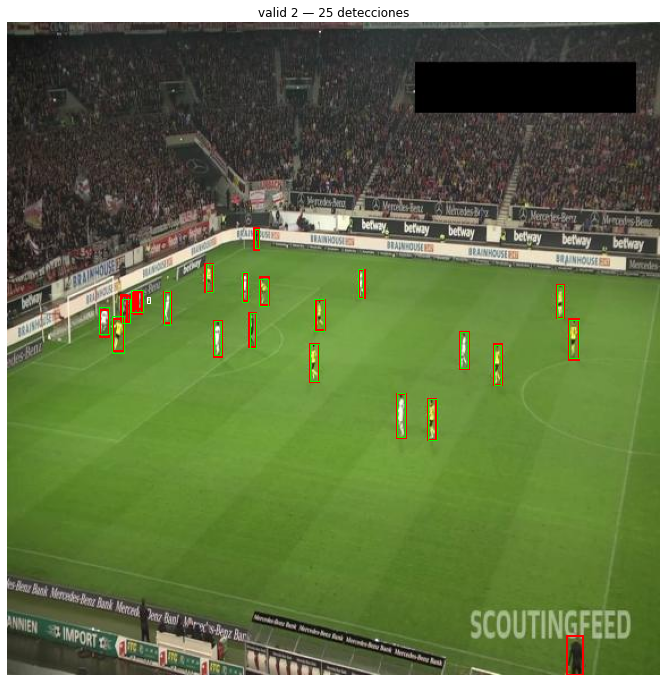

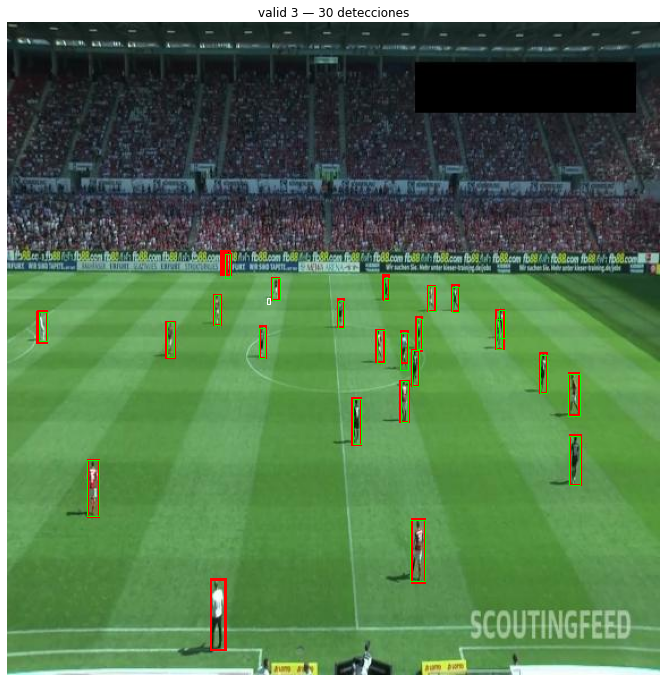

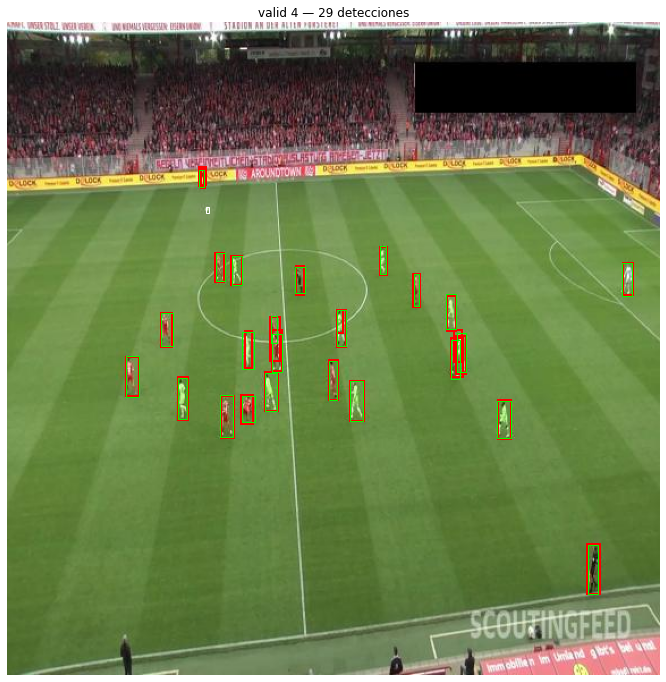

In [13]:
from torchvision.transforms.functional import to_tensor
from src.viz import dibujarCajas
import matplotlib.pyplot as plt

PERSONAS = {2, 3, 4}
UMBRAL   = 0.20
IDS      = [0, 1, 2, 3, 4]

for img_id in IDS:
    x = to_tensor(ds.imagen(img_id))

    with torch.no_grad():
        pred = modelo([x])[0]

    pares = [(b, "pred")
             for b, l, s in zip(pred["boxes"].tolist(),
                                pred["labels"].tolist(),
                                pred["scores"].tolist())
             if int(l) in PERSONAS and s >= UMBRAL]

    fig, ax = plt.subplots(figsize=(12, 12))
    ax.imshow(ds.imagen(img_id))
    ax.axis("off")
    ax.set_title(f"valid {img_id} — {len(pares)} detecciones")
    dibujarCajas(ax, pares, colores={"pred": "red"}, grosor=2)
    dibujarCajas(ax, ds.cajas(img_id),
                 colores={"player": "lime", "goalkeeper": "lime", "referee": "lime"},
                 grosor=1)
    plt.show()
